In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO
from azure.storage.blob import BlobServiceClient
from tqdm import tqdm

# Configuration
STORAGE_ACCOUNT = "solarflarestorageproject"
STORAGE_KEY = os.environ.get("AZURE_STORAGE_KEY", "")
RAW_CONTAINER = "raw"

print("Configuration loaded successfully.")

Configuration loaded successfully.


In [2]:
import os
os.environ["AZURE_STORAGE_KEY"] = ""
STORAGE_KEY = os.environ.get("AZURE_STORAGE_KEY", "")
print("Key set for this session.")

Key set for this session.


In [3]:
# Connect to Azure Blob Storage
container_client = BlobServiceClient(
    account_url=f"https://{STORAGE_ACCOUNT}.blob.core.windows.net",
    credential=STORAGE_KEY
).get_container_client(RAW_CONTAINER)

blobs = list(container_client.list_blobs())
df = pd.DataFrame({"blob_name": [b.name for b in blobs]})

print(f"Connected successfully.")
print(f"Total images found: {len(df)}")

Connected successfully.
Total images found: 268231


In [4]:
def parse_active_region(blob_name):
    """Extract NOAA active region number from blob path.
    Note: flare class labels require the companion metadata CSV from Zenodo.
    Path format: magnetograms/dataset_folder/NOAA_AR_number/filename.png
    """
    parts = blob_name.split("/")
    if len(parts) >= 3:
        return parts[2]
    return "unknown"

if len(df) > 0:
    df["active_region"] = df["blob_name"].apply(parse_active_region)
    print("Top 10 most frequent active regions:")
    print(df["active_region"].value_counts().head(10))
    print(f"\nTotal images: {len(df)}")
    print(f"Total unique active regions: {df['active_region'].nunique()}")
else:
    print("No data available yet. Cell will execute fully once dataset is uploaded.")

Top 10 most frequent active regions:
2443    1055
2241    1054
2625    1051
2565    1049
2598    1045
2327    1042
1612    1041
2077    1041
2102    1037
2480    1030
Name: active_region, dtype: int64

Total images: 268231
Total unique active regions: 448


In [5]:
def sample_pixel_stats(container_client, df, n_samples=100):
    """Sample n images and compute pixel-level statistics."""
    if len(df) == 0:
        return None

    sample = df.sample(min(n_samples, len(df)))
    stats = []

    for _, row in tqdm(sample.iterrows(), total=len(sample)):
        try:
            data = container_client.download_blob(row["blob_name"]).readall()
            img = Image.open(BytesIO(data)).convert("L")
            arr = np.array(img).astype(np.float32)
            stats.append({
                "blob_name":    row["blob_name"],
                "active_region": row["active_region"],
                "mean_pixel":   arr.mean(),
                "std_pixel":    arr.std(),
                "min_pixel":    arr.min(),
                "max_pixel":    arr.max(),
            })
        except Exception as e:
            print(f"Error processing {row['blob_name']}: {e}")
            continue

    return pd.DataFrame(stats)

if len(df) > 0:
    stats_df = sample_pixel_stats(container_client, df)
    print(stats_df.describe())
else:
    print("No data available yet. Cell will execute fully once dataset is uploaded.")

 55%|█████▌    | 55/100 [00:00<00:00, 108.51it/s]

       mean_pixel   std_pixel   min_pixel   max_pixel
count  100.000000  100.000000  100.000000  100.000000
mean   127.564415    4.442677   66.959999  187.899994
std      0.484683    2.594921   22.021532   23.064470
min    126.377769    1.388981    0.000000  147.000000
25%    127.348396    2.750999   49.750000  170.500000
50%    127.504482    3.924119   68.500000  186.500000
75%    127.641651    5.393928   84.250000  200.250000
max    129.420181   17.767796  103.000000  255.000000


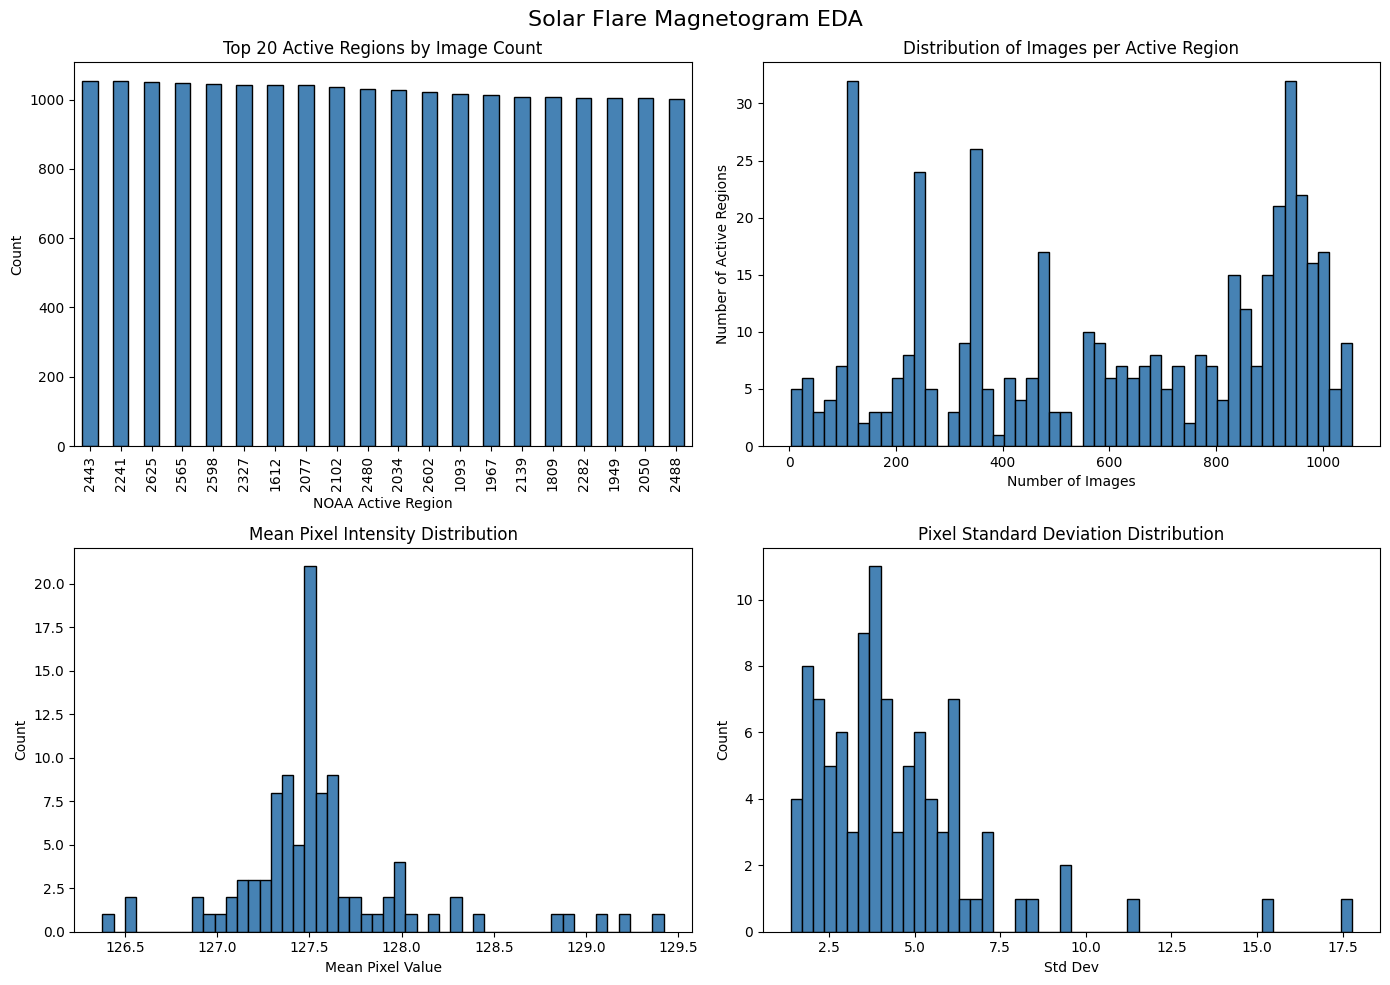

Plots saved to outputs/eda_plots.png


In [6]:
def plot_eda(df, stats_df):
    """Generate EDA plots."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Solar Flare Magnetogram EDA", fontsize=16)

    # Plot 1: Top 20 active regions by image count
    df["active_region"].value_counts().head(20).plot(
        kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="black")
    axes[0, 0].set_title("Top 20 Active Regions by Image Count")
    axes[0, 0].set_xlabel("NOAA Active Region")
    axes[0, 0].set_ylabel("Count")
    axes[0, 0].tick_params(axis="x", rotation=90)

    # Plot 2: Images per active region distribution
    axes[0, 1].hist(df["active_region"].value_counts().values, bins=50, color="steelblue", edgecolor="black")
    axes[0, 1].set_title("Distribution of Images per Active Region")
    axes[0, 1].set_xlabel("Number of Images")
    axes[0, 1].set_ylabel("Number of Active Regions")

    # Plot 3: Mean pixel intensity distribution
    axes[1, 0].hist(stats_df["mean_pixel"], bins=50, color="steelblue", edgecolor="black")
    axes[1, 0].set_title("Mean Pixel Intensity Distribution")
    axes[1, 0].set_xlabel("Mean Pixel Value")
    axes[1, 0].set_ylabel("Count")

    # Plot 4: Pixel std distribution
    axes[1, 1].hist(stats_df["std_pixel"], bins=50, color="steelblue", edgecolor="black")
    axes[1, 1].set_title("Pixel Standard Deviation Distribution")
    axes[1, 1].set_xlabel("Std Dev")
    axes[1, 1].set_ylabel("Count")

    plt.tight_layout()
    os.makedirs("outputs", exist_ok=True)
    plt.savefig("outputs/eda_plots.png", dpi=150)
    plt.show()
    print("Plots saved to outputs/eda_plots.png")

if len(df) > 0:
    plot_eda(df, stats_df)
else:
    print("No data available yet. Cell will execute fully once dataset is uploaded.")

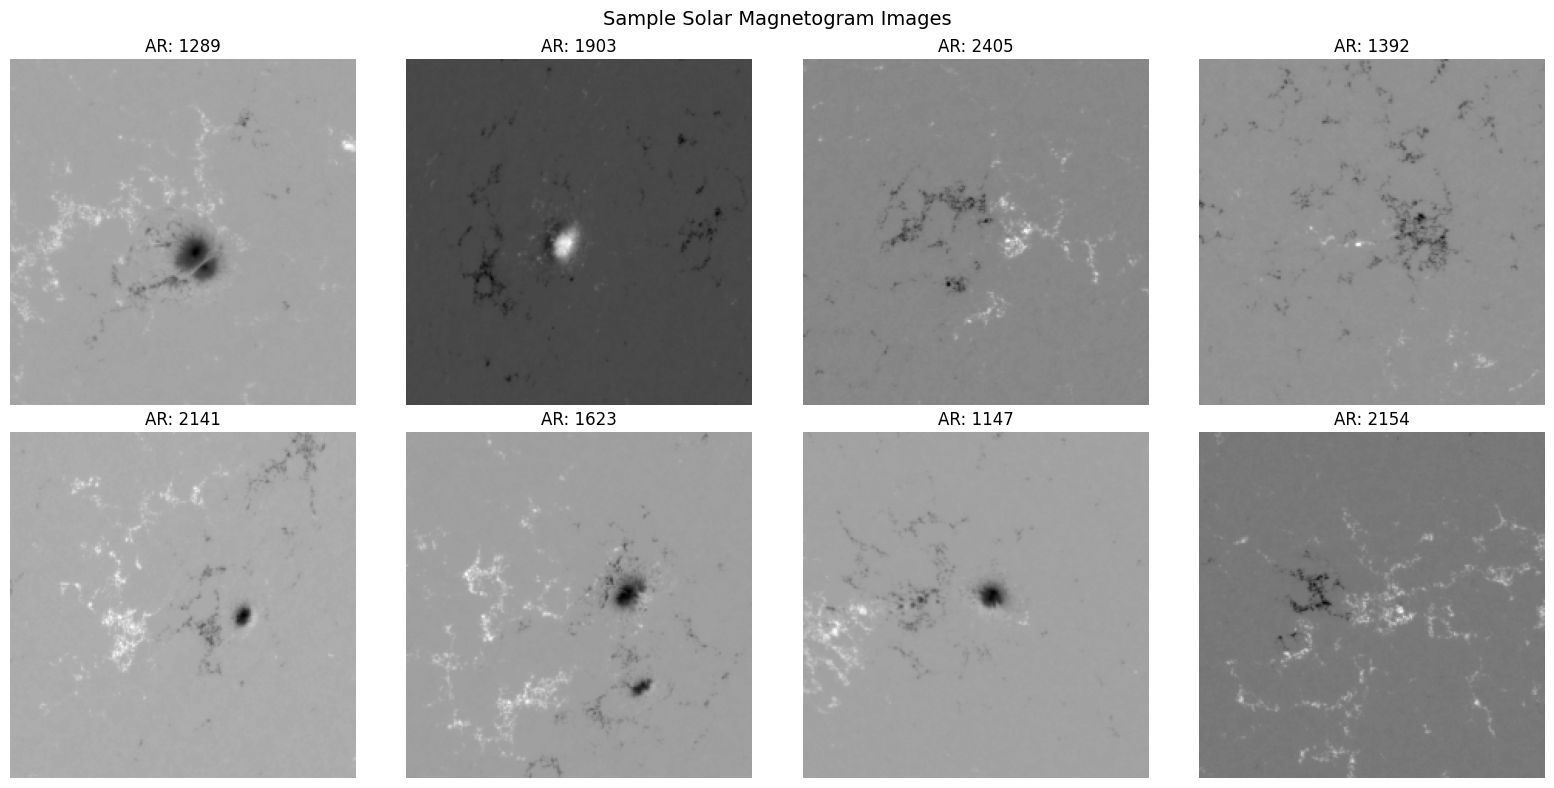

Sample images saved to outputs/sample_images.png


In [7]:
def show_sample_images(container_client, df, n=8):
    """Display a grid of sample magnetogram images."""
    if len(df) == 0:
        print("No data available yet. Cell will execute fully once dataset is uploaded.")
        return

    sample = df.sample(min(n, len(df)))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Sample Solar Magnetogram Images", fontsize=14)
    axes = axes.flatten()

    for i, (_, row) in enumerate(sample.iterrows()):
        try:
            data = container_client.download_blob(row["blob_name"]).readall()
            img = Image.open(BytesIO(data)).convert("L")
            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(f"AR: {row['active_region']}")
            axes[i].axis("off")
        except Exception as e:
            axes[i].set_title("Error loading image")
            axes[i].axis("off")

    plt.tight_layout()
    os.makedirs("outputs", exist_ok=True)
    plt.savefig("outputs/sample_images.png", dpi=150)
    plt.show()
    print("Sample images saved to outputs/sample_images.png")

show_sample_images(container_client, df)

In [8]:
print(df["blob_name"].head(10).tolist())

['magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_000000_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_001200_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_002400_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_003600_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_004800_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_010000_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_011200_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_012400_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.M_720s.20100503_013600_TAI.1.magnetogram_224.png', 'magnetograms/Lat60_Lon60_Nans0_png_224/1065/1065_hmi.